<a href="https://colab.research.google.com/github/Vixuz144/Simulacion-1/blob/main/Lineas_de_espera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

4.93459240584601


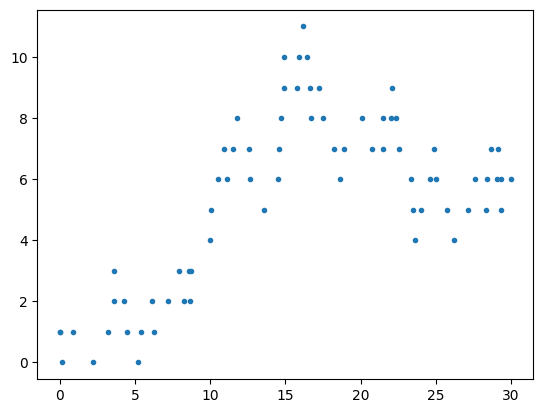

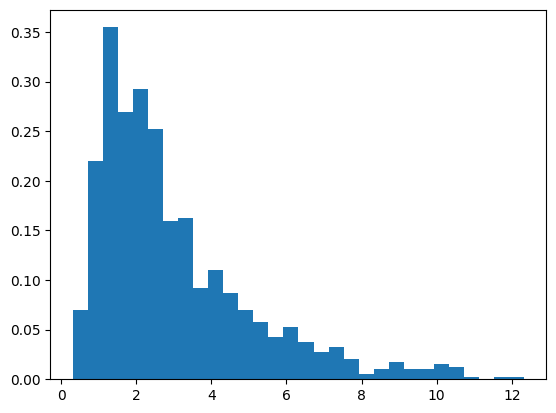

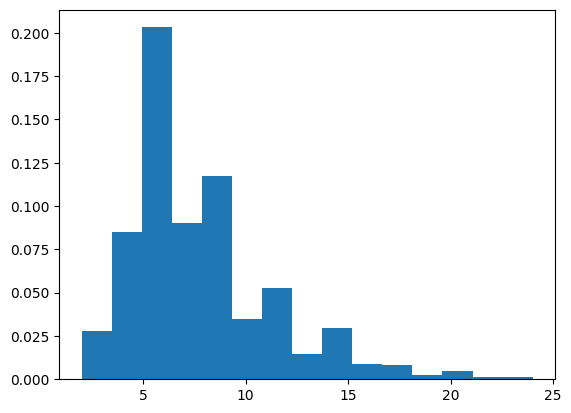

In [ ]:
from random import random
import numpy as np
import matplotlib.pyplot as plt
from numba import jit

@jit(nopython = True)
def linea_espera(T, ll, ls):
  lista_tiempos, lista_individuos = [0], [1]
  tl = 0
  ts = np.inf
  t = 0
  l = 0
  suma = 0
  maximo = 0
  while min(ts,tl) < T:
    ta = t
    t = min(ts,tl)
    suma += l*(t-ta)
    if maximo < l:
      maximo = l
    if t == tl:
      l += 1
      #print(t, l)
      tl = t - 1/ll * np.log(random())
      if l == 1:
        ts = t - 1/ls * np.log(random())
    else :
      l -= 1
      #print("\t\t\t", t, l)
      if l == 0:
        ts = np.inf
      else:
        ts = t - 1/ls * np.log(random())
    lista_tiempos.append(t)
    lista_individuos.append(l)
  suma += l*(T- t)
  return lista_tiempos, lista_individuos, suma/T, maximo

x, y, med, maxi = linea_espera(30, 1.1, 1.3)

print(med)

fig = plt.plot(x,y, ".")
plt.show(fig)

nr = 1000
l = []
lmax = []
for i in range(nr):
   l.append(linea_espera(30, 1.1, 1.3)[-2])
   lmax.append(linea_espera(30, 1.1, 1.3)[-1])

plt.hist(l, bins = 30, density = True)
plt.figure()
plt.hist(lmax, bins = 15, density = True)

med = np.mean(l)
var = np.var(l, ddof=1)
desv = np.std(l, ddof=1)

In [ ]:
from random import random
import numpy as np
import matplotlib.pyplot as plt
from numba import jit

# @jit(nopython = True)
def linea_espera(T, ll, ls):
  tl = 0
  ts = np.inf
  t = 0
  l = 0
  suma = 0
  m = []
  while min(ts,tl) < T:
    ta = t
    t = min(ts, tl)
    if l == 0:
      suma += t-ta
      m.append(t-ta)
    if t == tl:
      l += 1
      # print(t,l)
      tl = t - 1/ll * np.log(random())
      if l == 1:
        ts = t - 1/ls * np.log(random())
    else:
      l -= 1
      # print("\t\t\t",t,l)
      if l == 0:
        ts = np.inf
      else:
        ts = t - 1/ls * np.log(random())
  return suma, max(m)



In [ ]:
nr = 1000
suma = 0
suma_max = 0
for i in range(nr):
  t, m = linea_espera(60,1.1,1.3)
  suma += t
  suma_max += m

print(suma/nr, suma_max/nr)

# nr = 100000
# suma = 0
# for i in range(nr):
#   suma += linea_espera(60, 1.1, 1.3)

# l = suma/nr
# print(suma)
# med = np.mean(l)
# var = np.var(l, ddof=1)
# desv = np.std(l, ddof=1)

# from scipy.stats import norm
# print(med)
# z = norm.ppf(0.975)
# print(med - z*desv/np.sqrt(nr), med + z*desv/np.sqrt(nr))

# # print()

# # med_max = np.mean(lmax)
# # var_max = np.var(lmax, ddof=1)
# # desv_max = np.std(lmax, ddof=1)

# # print(med_max)
# # print(med_max - z*desv_max/np.sqrt(nr), med_max + z*desv_max/np.sqrt(nr))
# # # print(np.mean(lt))

11.775696307559896 2.7226690346196825


In [ ]:
max([0,10,2])